# E1 213 Pattern Recognition and Neural Network - Assignment 1
***
*Submitted by: Dwaipayan Haldar*<br>
*S.R. No. : 27128*

In [1]:
import numpy as np
import os
import matplotlib.pyplot as plt
np.random.seed(42)
import time

from src import *

### Phase 1: Bio-Optic Sensor Calibration

In [2]:
data = load_data('dataset_1.csv')

#### Problem 1.1

In [3]:
model = ordinary_least_squares()
W_1 = model.gradient_descent_fit(data[:,0],data[:,1])
W_2 = model.normal_equation_fit(data[:,0],data[:,1])

print(f"L2 norm of the difference of the final weight vectors is {np.linalg.norm(W_1-W_2)}")

L2 norm of the difference of the final weight vectors is 1.6207735234714224e-14


#### Problem 1.2

In [4]:
X = data[:,0]
y = data[:,1]
y_binary = np.where(y>=np.median(y),1,-1)

model = hard_margin_svm(X, y_binary)

mu = model.optimal_mu()

idx = mu > 1e-5
exact_index = np.arange(len(y))[idx]
print("Exact indexes of support vectors", exact_index)

     pcost       dcost       gap    pres   dres
 0: -1.2401e+03 -2.6033e+03  2e+04  1e+02  2e+00
 1: -2.7096e+03 -3.3614e+03  1e+04  6e+01  1e+00
 2: -3.5991e+03 -4.4456e+03  1e+04  6e+01  1e+00
 3: -4.3407e+03 -5.3609e+03  1e+04  6e+01  1e+00
 4: -4.6635e+04 -5.6129e+04  1e+04  6e+01  1e+00
 5: -3.0298e+05 -3.0963e+05  7e+03  5e+01  1e+00
 6: -1.3871e+06 -1.4153e+06  3e+04  5e+01  1e+00
 7: -2.8324e+06 -2.8887e+06  6e+04  5e+01  1e+00
 8: -2.9091e+06 -2.9669e+06  6e+04  5e+01  1e+00
 9: -1.4993e+08 -1.4998e+08  5e+04  5e+01  1e+00
10: -1.6865e+11 -1.6869e+11  4e+07  5e+01  1e+00
11: -2.8348e+11 -2.8354e+11  6e+07  5e+01  1e+00
12: -3.9382e+11 -3.9390e+11  8e+07  5e+01  1e+00
13: -4.0845e+11 -4.0853e+11  8e+07  5e+01  1e+00
14: -6.0153e+11 -6.0164e+11  1e+08  5e+01  1e+00
15: -8.8230e+11 -8.8244e+11  1e+08  5e+01  1e+00
16: -1.9809e+12 -1.9810e+12  1e+08  5e+01  1e+00
Terminated (singular KKT matrix).
Exact indexes of support vectors [   0    1    2 ... 4997 4998 4999]


### Phase 2: Oncology Array

In [3]:
data_2 = load_data('dataset_2.csv')

#### Problem 2.3

The condition number for the OLS: 9.66610655124181e+18


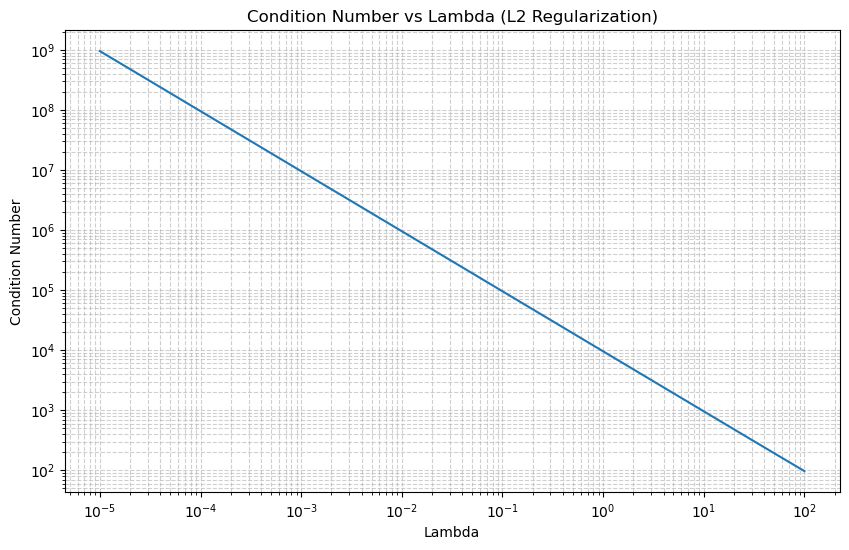

In [5]:
model = regression(data_2)
ols_weights, ols_condition_number = model.ordinary_least_squares()
print(f"The condition number for the OLS: {ols_condition_number}")

lambdas = np.logspace(-5, 2, num=50)
l2_condition_number_track = []
for lammbda in lambdas:
    l2_weights, l2_condition_number = model.l2_regression(lammbda)
    l2_condition_number_track.append(l2_condition_number)

plt.figure(figsize=(10, 6))
plt.plot(lambdas, l2_condition_number_track)
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Lambda')
plt.ylabel('Condition Number')
plt.title('Condition Number vs Lambda (L2 Regularization)')
plt.grid(True, which='both', linestyle='--', alpha=0.6)
plt.show()

#### Problem 2.4

The percentage of non-zero for 0.01 is 0.951048951048951
The percentage of non-zero for 0.012067926406393288 is 0.945054945054945
The percentage of non-zero for 0.014563484775012436 is 0.9430569430569431
The percentage of non-zero for 0.017575106248547922 is 0.9310689310689311
The percentage of non-zero for 0.021209508879201904 is 0.9150849150849151
The percentage of non-zero for 0.025595479226995357 is 0.9070929070929071
The percentage of non-zero for 0.030888435964774818 is 0.8831168831168831
The percentage of non-zero for 0.0372759372031494 is 0.8631368631368631
The percentage of non-zero for 0.04498432668969444 is 0.8451548451548452
The percentage of non-zero for 0.054286754393238594 is 0.8041958041958042
The percentage of non-zero for 0.0655128556859551 is 0.7832167832167832
The percentage of non-zero for 0.07906043210907697 is 0.7562437562437563
The percentage of non-zero for 0.09540954763499938 is 0.7212787212787213
The percentage of non-zero for 0.1151395399326447 is 0.69330669

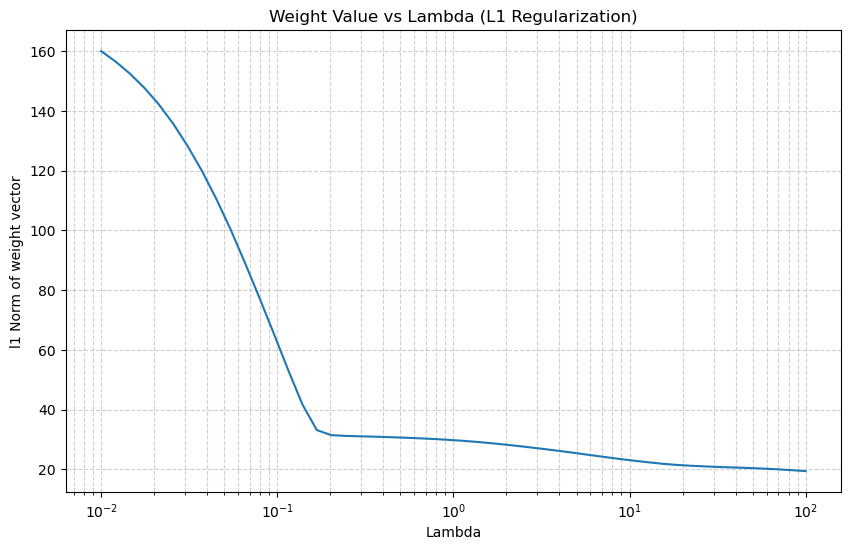

The lambda for which exactly 0.5 coefficient is zero is 0.37


In [8]:
model = regression(data_2)
lambdas = np.logspace(-2, 2, num=50)
w_l1_track = []
l0_track = []
for lammbda in lambdas:
    l1_weights, l0_number = model.l1_regression(lammbda)
    l0_track.append(l0_number)
    w_l1_track.append(np.linalg.norm(l1_weights, ord = 1))
    print(f"The percentage of non-zero for {lammbda} is {l0_number}")

plt.figure(figsize=(10, 6))
plt.plot(lambdas, w_l1_track)
# plt.yscale('log')
plt.xscale('log')
plt.xlabel('Lambda')
plt.ylabel('l1 Norm of weight vector')
plt.title('Weight Value vs Lambda (L1 Regularization)')
plt.grid(True, which='both', linestyle='--', alpha=0.6)
plt.show()

best_lambda = 0
for lammbda in np.linspace(0.32,0.37, num = 20):
    l1_weights, l0_number = model.l1_regression(lammbda)
    l0_number = round(l0_number, 2)
    if l0_number == 0.50:
        best_lambda = lammbda

if best_lambda:
    print(f"The lambda for which exactly 0.5 coefficient is zero is {best_lambda}")

### Phase 3: High Frequency ICU Telemetry

In [5]:
data_3 = load_data('dataset_3.csv')

#### Problem 3.5

Lipschitz constant L = 294.4399
Max safe learning rate alpha < 0.003396


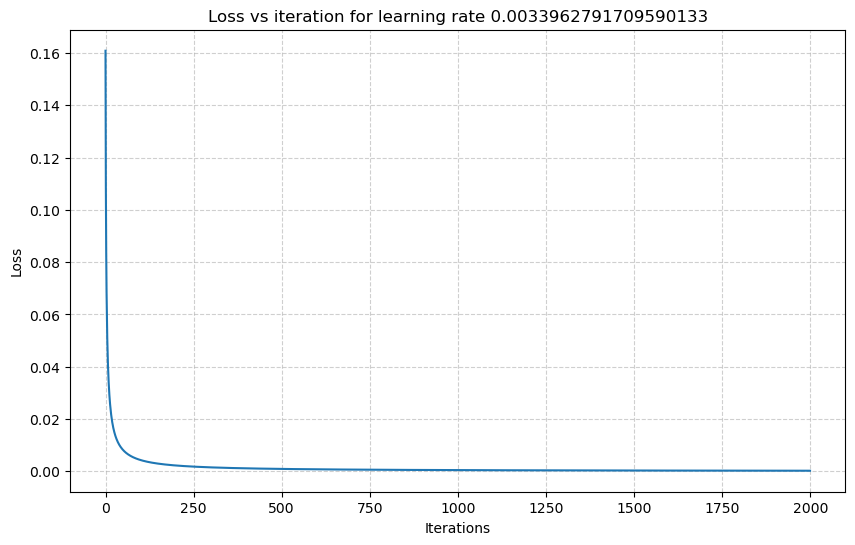

/Users/dwaipayanhaldar/Downloads/Notes and Books/IISc Coding Assignments and Project/E1-213-Pattern-Recognition-Neural-Network/Assignment_1/src.py:213: RuntimeWarning: overflow encountered in exp
  return 1/(1+np.exp(-x))


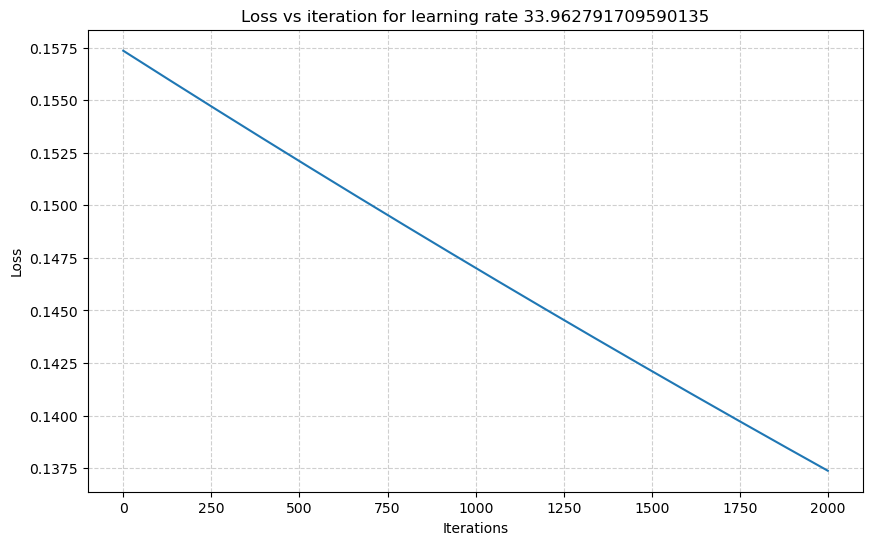

In [6]:
model = logistic_regression(data_3)
L = model.lipschitz_constant(laambda=0.01)
print(f"Lipschitz constant L = {L:.4f}")
print(f"Max safe learning rate alpha < {1/L:.6f}")
w_low_lr, loss_track_low_lr = model.logistic_regression(alpha=1/L, laambda=0.01)
w_high_lr, loss_track_high_lr = model.logistic_regression(alpha=10000/L, laambda=0.01)

#### Problem 3.6

In [7]:
model = gaussian_mixture(data_3)
initial_ll, later_ll, alpha, mu, sigma = model.expectation_maximization(4,1)
print(f"The initial marginal log likelihood is {initial_ll} and the log likelihood after one iteration is {later_ll[0]}")

The initial marginal log likelihood is -2857267.241862903 and the log likelihood after one iteration is -1771352.3843269728


#### Problem 3.7

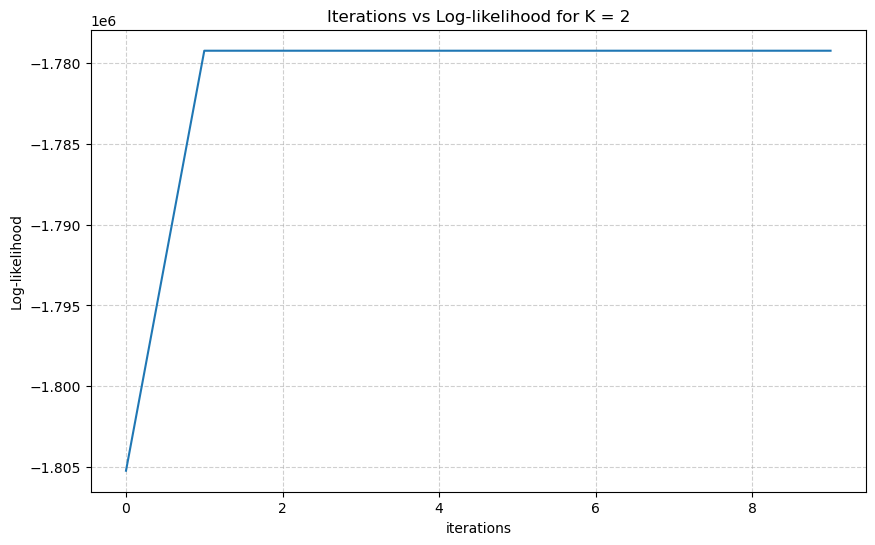

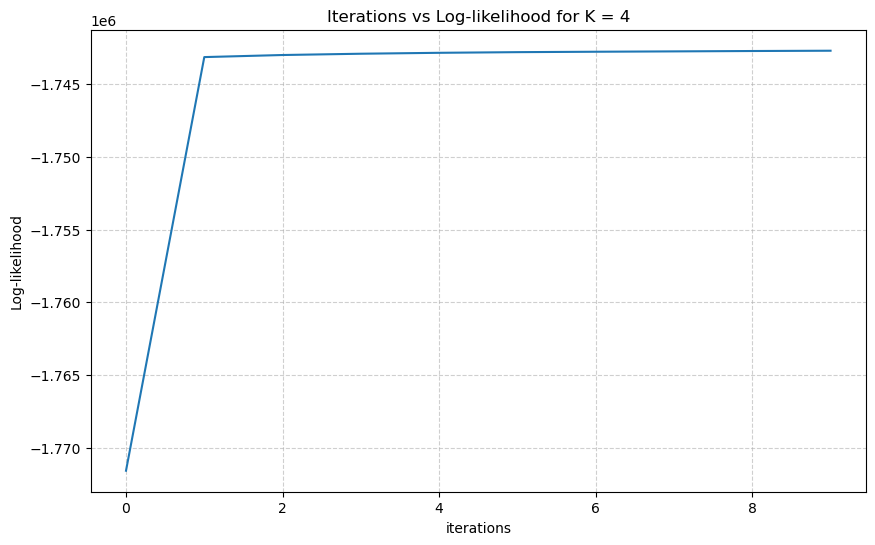

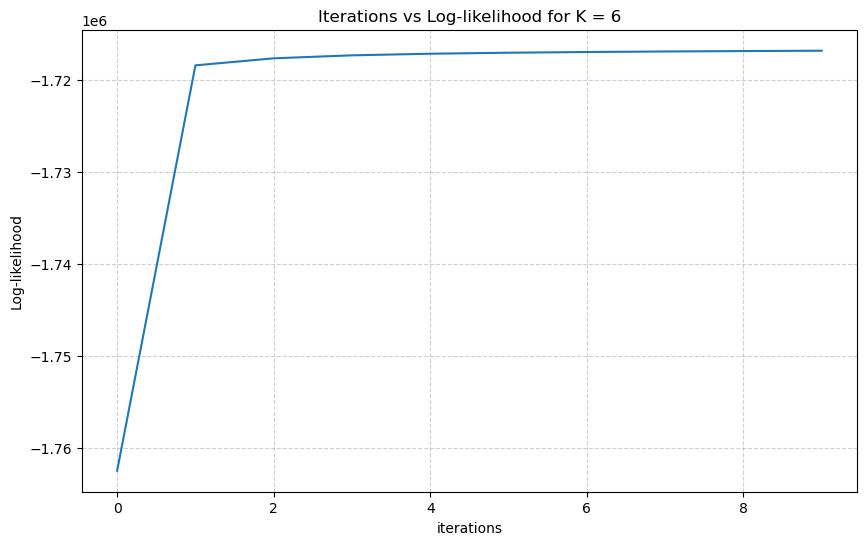

LinAlgError: When `allow_singular is False`, the input matrix must be symmetric positive definite.

In [34]:
np.random.seed(100)

model = gaussian_mixture(data_3)
iterations = 10

for k in [2,4,6]:
    initial_ll,later_ll,_,__,___ = model.expectation_maximization(k, iterations)
    plt.figure(figsize=(10, 6))
    plt.plot(np.arange(iterations), later_ll)
    plt.xlabel('iterations')
    plt.ylabel('Log-likelihood')
    plt.title(f'Iterations vs Log-likelihood for K = {k}')
    plt.grid(True, which='both', linestyle='--', alpha=0.6)
    plt.show()

#Forcing one of the covariance matrix to 0 mid training 
model.expectation_maximization(4,10,crash=True)

#### Problem 3.8

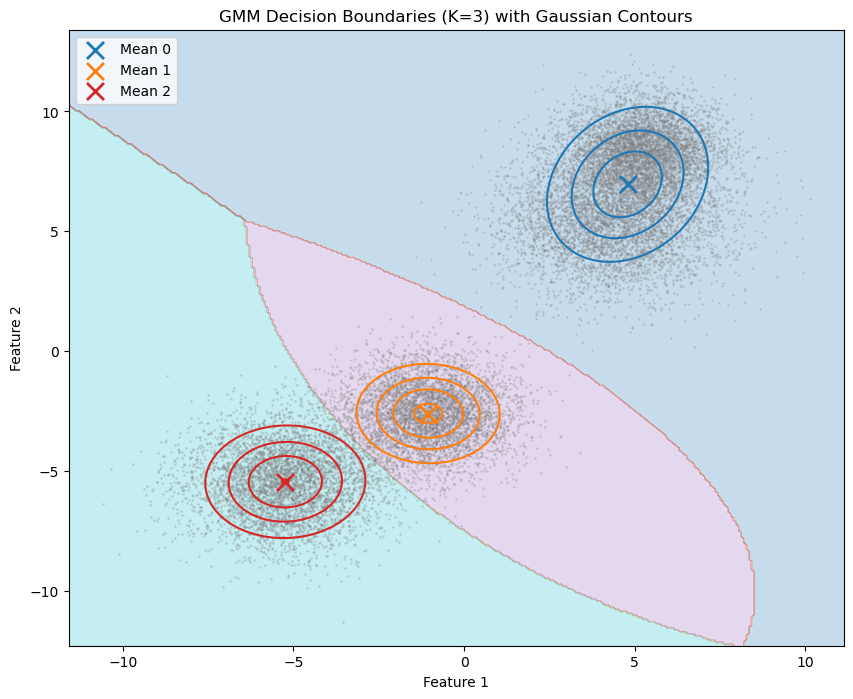

In [23]:
np.random.seed(42)

model = gaussian_mixture(data_3)
model.decision_boundary()

#### Problem 3.9

In [19]:
model = soft_margin_classifier(data_3)
optimal_mu = model.optimal_mu(1)

print(f"Index of point exactly on the margin {np.where(optimal_mu == np.max(optimal_mu))} and the value of mu for this is {np.max(optimal_mu)}")
print(f"Index of point classified safely outside the margin {np.where(optimal_mu == np.min(optimal_mu))} and the value of mu for this is {np.min(optimal_mu)}")
print("No point classified outside the margin")

     pcost       dcost       gap    pres   dres
 0: -4.6087e+01 -1.2891e+04  6e+04  2e+00  7e-11
 1: -1.9098e+01 -4.7537e+03  7e+03  1e-01  2e-11
 2: -8.8156e-01 -2.8453e+02  4e+02  6e-03  6e-12
 3: -5.8230e-03 -3.1727e+00  4e+00  7e-05  3e-13
 4:  1.6365e-03 -1.6683e-01  2e-01  4e-06  2e-14
 5:  8.0012e-04 -5.9668e-03  7e-03  3e-08  5e-15
 6: -6.4166e-04 -1.5163e-03  9e-04  1e-09  5e-15
 7: -7.5689e-04 -1.5409e-03  8e-04  7e-10  3e-15
 8: -8.0020e-04 -1.4733e-03  7e-04  5e-10  2e-15
 9: -8.2286e-04 -1.4958e-03  7e-04  5e-10  2e-15
10: -1.0130e-03 -1.4127e-03  4e-04  7e-11  2e-15
11: -1.0251e-03 -1.3906e-03  4e-04  4e-11  1e-15
12: -1.0652e-03 -1.3200e-03  3e-04  2e-11  2e-15
13: -1.0846e-03 -1.2629e-03  2e-04  2e-16  2e-15
14: -1.1347e-03 -1.1967e-03  6e-05  2e-16  2e-15
15: -1.1630e-03 -1.1645e-03  2e-06  2e-16  3e-15
16: -1.1637e-03 -1.1638e-03  2e-08  2e-16  8e-15
Optimal solution found.
Index of point exactly on the margin (array([3374]),) and the value of mu for this is 0.0004879

#### Problem 3.10

In [11]:
model = soft_margin_classifier(data_3)
K, evals = model.rbf_kernel(0.01, model.X1, eval=True)

print(f"The max eigen value is {np.max(evals)} and the min eigen value is {np.min(evals)}")

The max eigen value is 1.0000000227373678 and the min eigen value is 0.9999999818101061


#### Problem 3.11

Iteration for C = 0.1, sigma = 0.001
     pcost       dcost       gap    pres   dres
 0: -2.3699e+03 -1.8659e+03  3e+04  2e+01  1e-16
 1: -7.9722e+02 -1.4630e+03  1e+03  4e-01  4e-16
 2: -6.8121e+02 -7.8211e+02  1e+02  5e-13  5e-16
 3: -6.8467e+02 -6.8586e+02  1e+00  2e-13  2e-16
 4: -6.8470e+02 -6.8471e+02  1e-02  3e-13  3e-16
 5: -6.8470e+02 -6.8470e+02  1e-04  2e-13  3e-16
Optimal solution found.
C=0.1, sigma=0.001, Train=0.552, Val=0.557
Iteration for C = 0.1, sigma = 0.01
     pcost       dcost       gap    pres   dres
 0: -2.3699e+03 -1.8659e+03  3e+04  2e+01  2e-16
 1: -7.9722e+02 -1.4630e+03  1e+03  4e-01  5e-16
 2: -6.8121e+02 -7.8211e+02  1e+02  2e-13  4e-16
 3: -6.8467e+02 -6.8586e+02  1e+00  2e-13  2e-16
 4: -6.8470e+02 -6.8471e+02  1e-02  1e-13  3e-16
 5: -6.8470e+02 -6.8470e+02  1e-04  4e-15  5e-16
Optimal solution found.
C=0.1, sigma=0.01, Train=0.552, Val=0.557
Iteration for C = 0.1, sigma = 0.1
     pcost       dcost       gap    pres   dres
 0: -2.3699e+03 -1.8659e+03

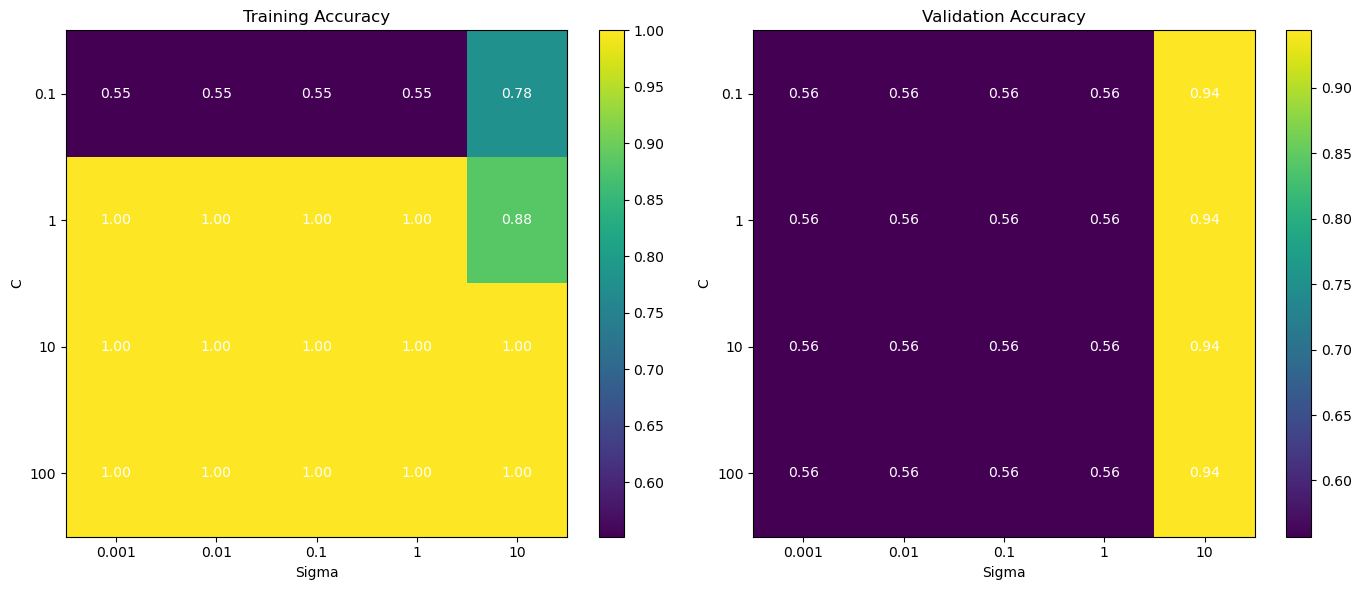

In [4]:
np.random.seed(42)

model = soft_margin_classifier(data_3)
idx = np.random.permutation(len(model.y))
train_idx = idx[:int(0.8*len(model.y))]
val_idx = idx[int(0.8*len(model.y)):]

C_list = [0.1,1,10,100]
sigma_list = [0.001,0.01,0.1,1,10]

train_acc_mat = np.zeros((len(C_list), len(sigma_list)))
val_acc_mat = np.zeros((len(C_list), len(sigma_list)))

for i, C in enumerate(C_list):
    for j, sigma in enumerate(sigma_list):
        tr_acc, val_acc = model.hyperparameter_topography(C,sigma, train_idx, val_idx)

        train_acc_mat[i, j] = tr_acc
        val_acc_mat[i, j] = val_acc

        print(f"C={C}, sigma={sigma}, Train={tr_acc:.3f}, Val={val_acc:.3f}")


fig, axes = plt.subplots(1, 2, figsize=(14,6))

mats = [train_acc_mat, val_acc_mat]
titles = ["Training Accuracy", "Validation Accuracy"]

for ax, mat, title in zip(axes, mats, titles):
    im = ax.imshow(mat, cmap='viridis', aspect='auto')

    ax.set_xticks(range(len(sigma_list)))
    ax.set_yticks(range(len(C_list)))
    ax.set_xticklabels(sigma_list)
    ax.set_yticklabels(C_list)

    ax.set_xlabel("Sigma")
    ax.set_ylabel("C")
    ax.set_title(title)

    # text values
    for i in range(len(C_list)):
        for j in range(len(sigma_list)):
            ax.text(j, i, f"{mat[i,j]:.2f}", ha='center', va='center', color='white')

    fig.colorbar(im, ax=ax)

plt.tight_layout()
plt.show()


### Phase 4: Unscaled Electronic Health Records

In [2]:
data_4 = load_data('dataset_4.csv')

#### Problem 4.12

The regression converged in 1195 iterations


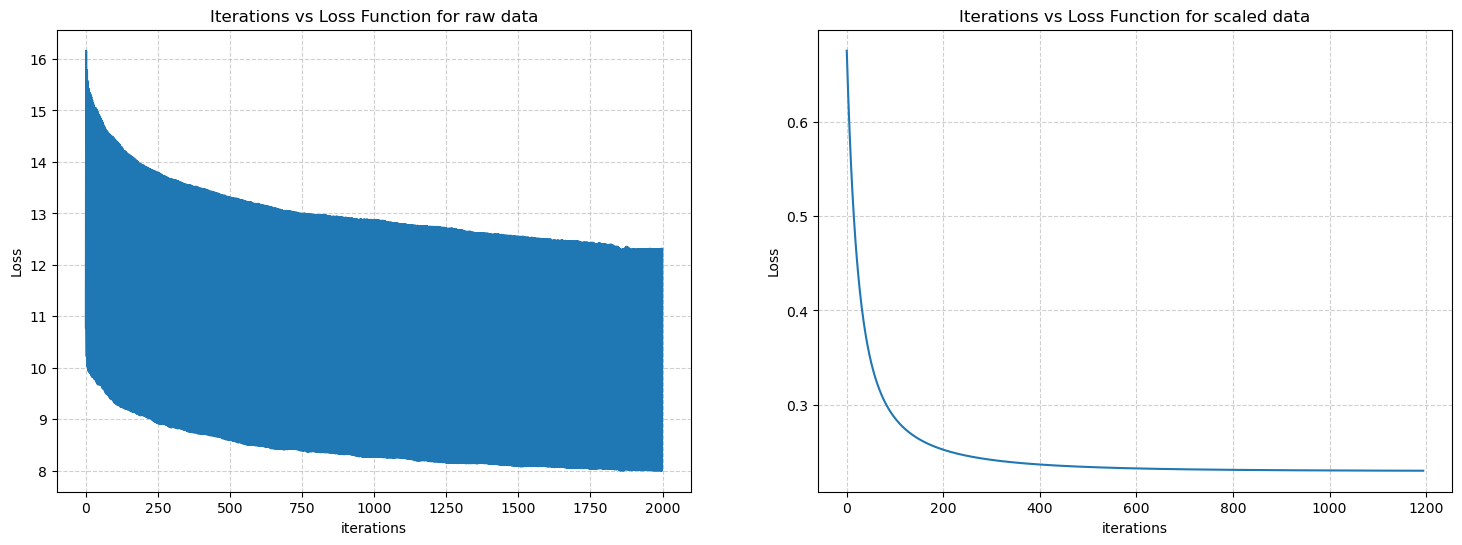

In [9]:
model = multi_class_logistic_regression(data_4)

no_of_iter, loss_track_raw = model.logistic_regression(0.001, 0.01)
no_of_iter_scaled, loss_track_scaled = model.logistic_regression(0.1, 0.01, standard_scaling=True)

plt.figure(figsize=(18,6))
plt.subplot(1,2,1)
plt.plot(np.arange(no_of_iter), loss_track_raw)
plt.xlabel('iterations')
plt.ylabel('Loss')
plt.title(f'Iterations vs Loss Function for raw data')
plt.grid(True, which='both', linestyle='--', alpha=0.6)
plt.subplot(1,2,2)
plt.plot(np.arange(no_of_iter_scaled), loss_track_scaled)
plt.xlabel('iterations')
plt.ylabel('Loss')
plt.title(f'Iterations vs Loss Function for scaled data')
plt.grid(True, which='both', linestyle='--', alpha=0.6)
plt.show()

#### Problem 4.13

In [5]:
np.random.seed(42)

model = k_nearest_neighbour(data_4)
idx = np.random.permutation(len(model.y))
train_idx = idx[:13000]
test_idx = idx[13000:]

start_time_naive = time.time()
y_pred,y_real = model.naive_knn(5, train_idx,test_idx)
end_time_naive = time.time()
print(f"The total time for running Naive KNN is {end_time_naive-start_time_naive}")

start_time_vector = time.time()
y_pred_vec, y_real_vec = model.vectorized_knn(5,train_idx,test_idx)
end_time_vector = time.time()
print(f"The total time for running Vectorized KNN is {end_time_vector-start_time_vector}")


The total time for running Naive KNN is 25.783467054367065
The total time for running Vectorized KNN is 0.5377378463745117


#### Problem 4.14

In [6]:
np.random.seed(42)

model = k_nearest_neighbour(data_4)
idx = np.random.permutation(len(model.y))
train_idx = idx[:13000]
test_idx = idx[13000:]

y_pred, y_real = model.vectorized_knn(5,train_idx,test_idx)
print(f"Accuracy without standard scaler is {np.sum(y_pred == y_real)/len(y_pred)}")

y_pred_ss, y_real_ss = model.vectorized_knn(5,train_idx, test_idx, standard_scaler=True)
print(f"Accuracy with standard scaler is {np.sum(y_pred_ss == y_real_ss)/len(y_pred_ss)}")

Accuracy without standard scaler is 0.8885
Accuracy with standard scaler is 0.9165


#### Problem 4.15

In [3]:
model = naive_bayes(data_4)

y_pred, y_true = model.naive_bayes_log()
print(f"There is no under flow in this case and the accuracy is {np.sum(y_pred == y_true)/len(y_pred)}")

model.naive_bayes_raw()


There is no under flow in this case and the accuracy is 0.9131333333333334
Underflow occurs at D = 28


28

### Phase 5: Bias-Variance Decomposition

In [2]:
data = load_data('dataset_1.csv')

#### Problem 5.16

In [8]:
np.random.seed(15)

model = empirical_bias_variance(data)
idx = np.random.permutation(len(model.y))
train_idx = idx[:int(0.8*len(model.y))]
test_idx = idx[int(0.8*len(model.y)):]

_,__,bias1, bias15,variance1, variance15 = model.empirical_bias_variance(train_idx,test_idx)

print(f"The bias of the d=1 model is {bias1} and the bias of the d=15 model is {bias15}")
print(f"The variance of the d=1 model is {variance1} and the variance of the d=15 model is {variance15}")

The bias of the d=1 model is 2.3319033135965257 and the bias of the d=15 model is 2.318060809787448
The variance of the d=1 model is 0.0010287732051929325 and the variance of the d=15 model is 0.010005157853601827


#### Problem 5.17

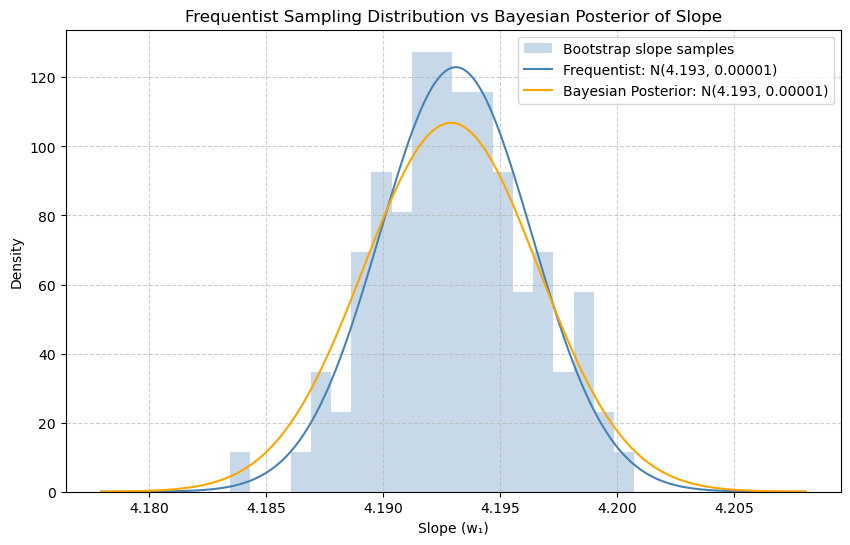

Frequentist variance : 0.000011
Bayesian post. var   : 0.000014


In [4]:
np.random.seed(15)

model = frequentist_vs_bayesian(data)
idx = np.random.permutation(len(model.y))

slopes, freq_mean, freq_var = model.frequentist(idx, B=100)
map_slope, post_var         = model.bayesian_map(idx, tau_sq=100.0)

x_lo = min(freq_mean, map_slope) - 4 * np.sqrt(max(freq_var, post_var))
x_hi = max(freq_mean, map_slope) + 4 * np.sqrt(max(freq_var, post_var))
x_range = np.linspace(x_lo, x_hi, 500)

freq_pdf  = sp.stats.norm.pdf(x_range, freq_mean, np.sqrt(freq_var))
bayes_pdf = sp.stats.norm.pdf(x_range, map_slope, np.sqrt(post_var))

plt.figure(figsize=(10, 6))
plt.hist(slopes, bins=20, density=True, alpha=0.3, color='steelblue', label='Bootstrap slope samples')
plt.plot(x_range, freq_pdf,  color='steelblue', label=f'Frequentist: N({freq_mean:.3f}, {freq_var:.5f})')
plt.plot(x_range, bayes_pdf, color='orange',    label=f'Bayesian Posterior: N({map_slope:.3f}, {post_var:.5f})')
plt.xlabel('Slope (w₁)')
plt.ylabel('Density')
plt.title('Frequentist Sampling Distribution vs Bayesian Posterior of Slope')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

print(f"Frequentist variance : {freq_var:.6f}")
print(f"Bayesian post. var   : {post_var:.6f}")
